In [0]:
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.getOrCreate()

silver_game = spark.table("workspace.silver_nba.game") \
    .filter(F.col("season_type") == "Regular Season") \
    .select("game_id", "team_id", "team_abbreviation", "season_year",
            "fga", "fg3a", "fta", "tov", "oreb", "pts", "ast", "fgm",
            "stl", "blk", "wl")

silver_other = spark.table("workspace.silver_nba.other_stats") \
    .select("game_id", "team_id", "pts_paint", "pts_fb", "pts_2nd_chance",
            "total_turnovers")

# Join on both game_id and team_id to ensure correct side matching
game_enriched = silver_game.join(silver_other, on=["game_id", "team_id"], how="left")

# Compute per-game style metrics before aggregating to season level
game_enriched = game_enriched \
    .withColumn("possessions", F.col("fga") - F.col("oreb") + F.col("tov") + (0.44 * F.col("fta"))) \
    .withColumn("ast_rate", F.expr("try_divide(ast, fgm)")) \
    .withColumn("fta_rate", F.expr("try_divide(fta, fga)")) \
    .withColumn("tov_rate", F.expr("try_divide(tov, possessions)")) \
    .withColumn("oreb_rate", F.expr("try_divide(oreb, fga)")) \
    .withColumn("pts_paint_rate", F.expr("try_divide(pts_paint, pts)")) \
    .withColumn("pts_fb_rate", F.expr("try_divide(pts_fb, pts)")) \
    .withColumn("pts_2nd_chance_rate", F.expr("try_divide(pts_2nd_chance, pts)")) \
    .withColumn("three_pt_rate", F.expr("try_divide(fg3a, fga)")) \
    .withColumn("def_aggression", F.col("stl") + F.col("blk"))

# Aggregate to team-season level
gold_style = game_enriched.groupBy("team_id", "team_abbreviation", "season_year") \
    .agg(
        F.count("game_id").alias("games_played"),
        F.avg("possessions").alias("pace"),
        F.avg("three_pt_rate").alias("three_pt_rate"),
        F.avg("fta_rate").alias("fta_rate"),
        F.avg("tov_rate").alias("tov_rate"),
        F.avg("oreb_rate").alias("oreb_rate"),
        F.avg("ast_rate").alias("ast_rate"),
        F.avg("pts_paint_rate").alias("pts_paint_rate"),
        F.avg("pts_fb_rate").alias("pts_fb_rate"),
        F.avg("pts_2nd_chance_rate").alias("pts_2nd_chance_rate"),
        F.avg("def_aggression").alias("def_aggression"),
        F.sum(F.when(F.col("wl") == "W", 1).otherwise(0)).alias("wins")
    ) \
    .filter(F.col("games_played") >= 20)

gold_style = gold_style.withColumn("win_pct", F.expr("try_divide(wins, games_played)"))

gold_style.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.gold_nba.style_fingerprints")

spark.sql("OPTIMIZE workspace.gold_nba.style_fingerprints ZORDER BY (season_year, team_id)")

print(f"Rows written: {gold_style.count():,}")
gold_style.filter(F.col("season_year") == 2015) \
    .orderBy(F.col("three_pt_rate").desc()) \
    .show(5)

Rows written: 1,519
+----------+-----------------+-----------+------------+------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+----+------------------+
|   team_id|team_abbreviation|season_year|games_played|              pace|      three_pt_rate|           fta_rate|           tov_rate|          oreb_rate|          ast_rate|    pts_paint_rate|        pts_fb_rate|pts_2nd_chance_rate|    def_aggression|wins|           win_pct|
+----------+-----------------+-----------+------------+------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+----+------------------+
|1610612745|              HOU|       2015|          82|101.01317073170729|  0.369878712837413| 0.3567841803167894| 0.1577059485894149|0.1347849014190099

In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession, functions as F
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

spark = SparkSession.builder.getOrCreate()

feature_cols = [
    "pace", "three_pt_rate", "fta_rate", "tov_rate",
    "oreb_rate", "ast_rate", "pts_paint_rate", "pts_fb_rate",
    "pts_2nd_chance_rate", "def_aggression"
]


df = spark.table("workspace.gold_nba.style_fingerprints") \
    .filter(F.col("pts_paint_rate").isNotNull()) \
    .filter(F.col("season_year") >= 2009) \
    .dropna(subset=feature_cols) \
    .toPandas()

print(f"Rows for clustering: {len(df)}")

# StandardScale
X = StandardScaler().fit_transform(df[feature_cols])

# Elbow method
print(f"\n{'K':>4s}  {'silhouette':>12s}")
print("-" * 20)

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"{k:>4d}  {score:>12.4f}")

Rows for clustering: 390

   K    silhouette
--------------------
   2        0.2423
   3        0.1619
   4        0.1418
   5        0.1259
   6        0.1301
   7        0.1223
   8        0.1175


In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# Profile each cluster -- what is the average style of each?
cluster_profile = df.groupby("cluster")[feature_cols + ["win_pct"]].mean().round(3)
cluster_profile["team_count"] = df.groupby("cluster")["team_id"].count()
print(cluster_profile.to_string())

            pace  three_pt_rate  fta_rate  tov_rate  oreb_rate  ast_rate  pts_paint_rate  pts_fb_rate  pts_2nd_chance_rate  def_aggression  win_pct  team_count
cluster                                                                                                                                                        
0         98.048          0.241     0.304     0.156      0.141     0.548           0.448        0.158                0.141          13.169    0.450          50
1        101.412          0.364     0.258     0.140      0.118     0.594           0.436        0.110                0.124          11.744    0.453          87
2         97.204          0.263     0.279     0.148      0.117     0.605           0.415        0.139                0.117          12.959    0.547          50
3         95.170          0.243     0.288     0.147      0.134     0.570           0.413        0.118                0.136          11.810    0.483          85
4        103.321          0.370     0.25

In [0]:
cluster_labels = {
    0: "Paint Dominant / Isolation",
    1: "Fast 3pt / Run and Gun",
    2: "Balanced / Halfcourt",
    3: "Slow / Defensive / Grind",
    4: "Warriors Style / Ball Movement",
    5: "Analytics Optimized / Efficient"
}

df["style_label"] = df["cluster"].map(cluster_labels)


print("2021 team cluster assignments:")
df[df["season_year"] == 2021][["team_abbreviation", "cluster", "style_label", "win_pct"]] \
    .sort_values("cluster") \
    .to_string(index=False)

2021 team cluster assignments:


'team_abbreviation  cluster                     style_label  win_pct\n              CLE        1          Fast 3pt / Run and Gun 0.536585\n              NOP        1          Fast 3pt / Run and Gun 0.439024\n              HOU        1          Fast 3pt / Run and Gun 0.243902\n              POR        1          Fast 3pt / Run and Gun 0.329268\n              IND        1          Fast 3pt / Run and Gun 0.304878\n              NYK        1          Fast 3pt / Run and Gun 0.451220\n              DEN        1          Fast 3pt / Run and Gun 0.585366\n              ORL        1          Fast 3pt / Run and Gun 0.268293\n              WAS        1          Fast 3pt / Run and Gun 0.426829\n              SAC        1          Fast 3pt / Run and Gun 0.365854\n              BOS        1          Fast 3pt / Run and Gun 0.621951\n              OKC        1          Fast 3pt / Run and Gun 0.292683\n              UTA        1          Fast 3pt / Run and Gun 0.597561\n              DET        1       

In [0]:
cluster_by_year = df.groupby(["season_year", "style_label"]).size().unstack(fill_value=0)
print(cluster_by_year.to_string())

style_label  Analytics Optimized / Efficient  Balanced / Halfcourt  Fast 3pt / Run and Gun  Paint Dominant / Isolation  Slow / Defensive / Grind  Warriors Style / Ball Movement
season_year                                                                                                                                                                     
2009                                       0                     5                       1                           7                        17                               0
2010                                       0                     7                       0                           9                        14                               0
2011                                       0                     7                       0                          10                        13                               0
2013                                       0                    10                       0                         

In [0]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

spark.sql("DROP TABLE IF EXISTS workspace.gold_nba.style_fingerprints")

gold_with_clusters = spark.createDataFrame(df)

gold_with_clusters.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.gold_nba.style_fingerprints")

print("Cluster assignments written to gold_nba.style_fingerprints")
print(f"Rows: {spark.table('workspace.gold_nba.style_fingerprints').count():,}")

Cluster assignments written to gold_nba.style_fingerprints
Rows: 390


In [0]:
import plotly.graph_objects as go
import pandas as pd

cluster_by_year = df.groupby(["season_year", "style_label"]).size().unstack(fill_value=0)

colors = {
    "Slow / Defensive / Grind": "#c8102e",
    "Paint Dominant / Isolation": "#e35d6a",
    "Balanced / Halfcourt": "#aaaaaa",
    "Fast 3pt / Run and Gun": "#1d428a",
    "Warriors Style / Ball Movement": "#ffc72c",
    "Analytics Optimized / Efficient": "#007a33",
}

fig = go.Figure()

for style in cluster_by_year.columns:
    fig.add_trace(go.Bar(
        x=cluster_by_year.index,
        y=cluster_by_year[style],
        name=style,
        marker_color=colors.get(style, "#888888")
    ))

fig.update_layout(
    barmode="stack",
    title="NBA Team Style Distribution 2009-2022",
    xaxis_title="Season",
    yaxis_title="Number of Teams",
    height=500,
    legend=dict(x=1.01, y=0.99),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [0]:
from pyspark.sql import SparkSession, functions as F
spark = SparkSession.builder.getOrCreate()

# Check game_summary for playoff round information
spark.table("workspace.bronze_nba.game_summary").show(3)

+-------------------+-------------+----------+--------------+----------------+---------------+------------+---------------+------+-----------+------------+--------------------------------+----------------------+---------+--------------------+----------+
|      game_date_est|game_sequence|   game_id|game_status_id|game_status_text|       gamecode|home_team_id|visitor_team_id|season|live_period|live_pc_time|natl_tv_broadcaster_abbreviation|live_period_time_bcast|wh_status|        _ingested_at|   _source|
+-------------------+-------------+----------+--------------+----------------+---------------+------------+---------------+------+-----------+------------+--------------------------------+----------------------+---------+--------------------+----------+
|1946-11-01 00:00:00|          nan|0024600001|             3|                |19461101/NYKHUS|  1610610035|     1610612752|  1946|          5|        None|                            None|                Q5  - |        1|2026-06-19T13:37:

In [0]:
# Check what season types exist in our game table
spark.table("workspace.silver_nba.game") \
    .groupBy("season_type", "season_year") \
    .count() \
    .filter(F.col("season_year") >= 2009) \
    .orderBy("season_year", "season_type") \
    .show(30)

+--------------+-----------+-----+
|   season_type|season_year|count|
+--------------+-----------+-----+
|      Playoffs|       2009|  164|
|Regular Season|       2009| 2460|
|      Playoffs|       2010|  162|
|Regular Season|       2010| 2460|
|      Playoffs|       2011|  168|
|Regular Season|       2011| 1980|
|      Playoffs|       2012|  170|
|      Playoffs|       2013|  178|
|Regular Season|       2013| 2460|
|      Playoffs|       2014|  162|
|Regular Season|       2014| 2460|
|      Playoffs|       2015|  172|
|Regular Season|       2015| 2460|
|      Playoffs|       2016|  158|
|Regular Season|       2016| 2460|
|      Playoffs|       2017|  164|
|Regular Season|       2017| 2460|
|      Playoffs|       2018|  164|
|Regular Season|       2018| 2460|
|      Playoffs|       2019|  166|
|Regular Season|       2019| 2118|
|      Playoffs|       2020|  170|
|Regular Season|       2020| 2160|
|      Playoffs|       2021|  174|
|Regular Season|       2021| 2460|
|      Playoffs|    

In [0]:
spark.table("workspace.silver_nba.game") \
    .filter(
        (F.col("season_type") == "Playoffs") &
        (F.col("season_year") == 2016)
    ) \
    .select("game_id", "team_abbreviation", "wl", "game_date") \
    .orderBy("game_id") \
    .show(20)

+----------+-----------------+---+----------+
|   game_id|team_abbreviation| wl| game_date|
+----------+-----------------+---+----------+
|0041600101|              CHI|  W|2017-04-16|
|0041600101|              BOS|  L|2017-04-16|
|0041600102|              CHI|  W|2017-04-18|
|0041600102|              BOS|  L|2017-04-18|
|0041600103|              BOS|  W|2017-04-21|
|0041600103|              CHI|  L|2017-04-21|
|0041600104|              BOS|  W|2017-04-23|
|0041600104|              CHI|  L|2017-04-23|
|0041600105|              BOS|  W|2017-04-26|
|0041600105|              CHI|  L|2017-04-26|
|0041600106|              CHI|  L|2017-04-28|
|0041600106|              BOS|  W|2017-04-28|
|0041600111|              IND|  L|2017-04-15|
|0041600111|              CLE|  W|2017-04-15|
|0041600112|              CLE|  W|2017-04-17|
|0041600112|              IND|  L|2017-04-17|
|0041600113|              CLE|  W|2017-04-20|
|0041600113|              IND|  L|2017-04-20|
|0041600114|              CLE|  W|

In [0]:
spark.table("workspace.silver_nba.game") \
    .filter(
        (F.col("season_type") == "Playoffs") &
        (F.col("season_year") == 2016)
    ) \
    .withColumn("playoff_round", F.substring("game_id", 8, 1).cast("integer")) \
    .groupBy("playoff_round") \
    .agg(F.count("game_id").alias("team_games")) \
    .orderBy("playoff_round") \
    .show()

+-------------+----------+
|playoff_round|team_games|
+-------------+----------+
|            1|        88|
|            2|        42|
|            3|        18|
|            4|        10|
+-------------+----------+



In [0]:
# Extract playoff round from game_id and find conference finalists per season
playoff_games = spark.table("workspace.silver_nba.game") \
    .filter(F.col("season_type") == "Playoffs") \
    .withColumn("playoff_round", F.substring("game_id", 8, 1).cast("integer"))

# A team reached conference finals if they appear in round 3 or 4
conference_finalists = playoff_games \
    .filter(F.col("playoff_round") >= 3) \
    .select("team_id", "season_year") \
    .distinct() \
    .withColumn("reached_conf_finals", F.lit(1))

# Join to style fingerprints -- these have our regular season features
gold_style = spark.table("workspace.gold_nba.style_fingerprints")

championship_features = gold_style \
    .join(conference_finalists, on=["team_id", "season_year"], how="left") \
    .fillna(0, subset=["reached_conf_finals"])

# Verify label distribution
championship_features.groupBy("reached_conf_finals").count().show()

+-------------------+-----+
|reached_conf_finals|count|
+-------------------+-----+
|                  1|   52|
|                  0|  338|
+-------------------+-----+



In [0]:
%pip install xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 200.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 MB 171.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import shap

# Pull to pandas
df_model = championship_features.toPandas()

feature_cols = [
    "pace", "three_pt_rate", "fta_rate", "tov_rate",
    "oreb_rate", "ast_rate", "pts_paint_rate", "pts_fb_rate",
    "pts_2nd_chance_rate", "def_aggression", "win_pct"
]

df_model = df_model.dropna(subset=feature_cols)

# Temporal split -- train on 2009-2018, test on 2019-2022
# Why temporal: we cannot use future data to predict past outcomes
train = df_model[df_model["season_year"] <= 2018]
test = df_model[df_model["season_year"] > 2018]

X_train = train[feature_cols]
y_train = train["reached_conf_finals"]
X_test = test[feature_cols]
y_test = test["reached_conf_finals"]

print(f"Train: {len(train)} rows, {y_train.sum()} positives")
print(f"Test:  {len(test)} rows, {y_test.sum()} positives")

# Train XGBoost with scale_pos_weight to handle class imbalance
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,          # shallow trees -- small dataset, avoid overfitting
    learning_rate=0.05,
    scale_pos_weight=338/52,
    random_state=42,
    eval_metric="auc"
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train: 270 rows, 36 positives
Test:  120 rows, 16 positives

ROC-AUC: 0.791

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       104
           1       0.41      0.56      0.47        16

    accuracy                           0.83       120
   macro avg       0.67      0.72      0.69       120
weighted avg       0.86      0.83      0.84       120



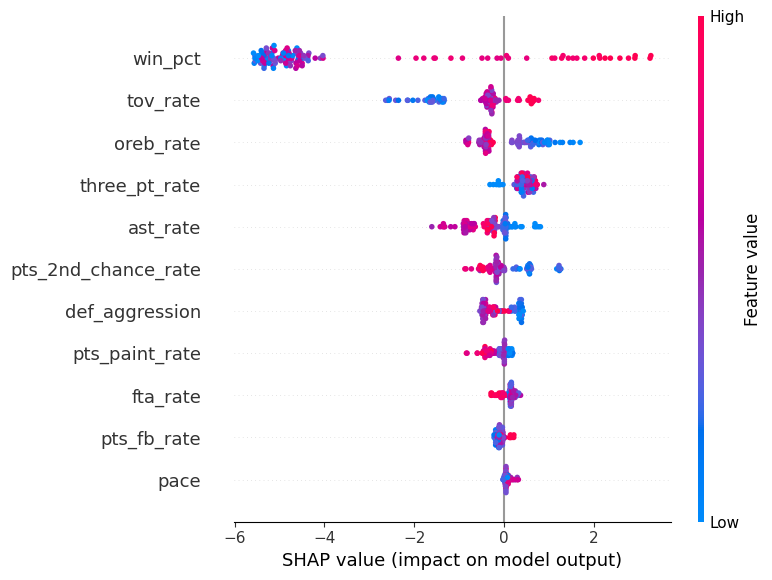

SHAP plot saved


In [0]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig("/tmp/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved")

In [0]:
import mlflow
import mlflow.xgboost

mlflow.set_experiment("/Shared/championship_dna")

with mlflow.start_run(run_name="xgboost_v1"):
    mlflow.log_param("scale_pos_weight", 338/52)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("train_seasons", "2009-2018")
    mlflow.log_param("test_seasons", "2019-2022")
    mlflow.log_metric("roc_auc", 0.791)
    mlflow.log_metric("precision_positive", 0.41)
    mlflow.log_metric("recall_positive", 0.56)
    mlflow.log_artifact("/tmp/shap_summary.png")
    mlflow.xgboost.log_model(model, "championship_dna_model")
    
    print("Model logged to MLflow")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2026/06/19 15:08:08 INFO mlflow.tracking.fluent: Experiment with name '/Shared/championship_dna' does not exist. Creating a new experiment.
2026/06/19 15:08:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-3033e85b-9133.cloud.databricks.com/ml/experiments/1081943741527801/models/m-b29cd10066fd41a39473805357566814?o=7474644387926823
2026/06/19 15:08:16 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Model logged to MLflow
Run ID: 647079ea6db549acaab10b3124b13f27
